# Generating financial returns with the same OT engine

The image half of this repo trains an OT-GAN (Salimans et al. 2018) on MNIST.
This notebook points the *unchanged* training engine at a smaller but harder
target: daily log-return paths. Asset returns have well-documented stylized
facts (Cont 2001) that any usable market generator must reproduce:

- **fat tails** — pooled excess kurtosis well above the Gaussian 0;
- **volatility clustering** — |r| and r² stay autocorrelated for tens of lags
  while r itself is nearly unpredictable;
- **leverage** — negative returns raise future volatility more than positive
  ones: corr(rₜ, r²ₜ₊ₖ) < 0.

Plain GANs struggle here: a per-sample discriminator happily accepts paths whose
*marginals* look right but whose temporal dependence is wrong, and adversarial
losses on tiny 1D samples are noisy. The OT-GAN objective is different in kind —
the **minibatch energy distance**: two independent real and two independent fake
minibatches compared through entropic optimal transport on critic embeddings.
Up to the choice of self-terms it equals **2× a debiased Sinkhorn divergence**
(Genevay, Peyré & Cuturi 2018; Feydy et al. 2019), so the critic compares
*distributions of paths* rather than path by path. That is the same family of
ideas the market-generator literature converged on: COT-GAN's causal Sinkhorn
divergences (Xu et al. 2020), Quant GANs (Wiese et al. 2020), Tail-GAN's
tail-risk objectives (Cont, Cucuringu, Xu & Zhang 2022) and Sig-WGANs on
signature features. Everything below reuses `otgan.energy.compute_loss`,
`otgan.sinkhorn.sinkhorn` and `otgan.ema.EMAGenerator` verbatim — *the same OT
engine, from images to markets*.

## 1. Setup and target

The target is **GJR-GARCH(1,1)** (Glosten, Jagannathan & Runkle 1993) — the
hardest of the repo's simulators: fat tails, volatility clustering *and* the
leverage asymmetry (γ > 0), which a symmetric GARCH lacks. The configuration is
`configs/finance_returns.yaml` unchanged except for three notebook-only knobs:
training outputs go to the gitignored `results/` directory, `n_steps` is reduced
from 3000 to 500 to keep this notebook's wall clock down (printed —
and discussed — below), and the evaluation/logging cadence is densified to match
the shorter run. Every optimization hyperparameter is the yaml value.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown

from otgan.finance.config import FinanceConfig
from otgan.finance.evaluate import (
    acf,
    sinkhorn_divergence_metric,
    stylized_facts_table,
    to_markdown,
)
from otgan.finance.trainer import ReturnsTrainer

REPO = Path.cwd().resolve()
if not (REPO / "configs").exists():  # executed from examples/
    REPO = REPO.parent
FIG_DIR = REPO / "assets" / "finance"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT = REPO / "results" / "finance"  # gitignored

cfg = FinanceConfig.from_yaml(REPO / "configs" / "finance_returns.yaml")
cfg.n_steps = 500  # yaml default: 3000; reduced for notebook wall clock
cfg.eval_every = 100  # logging/eval cadence only; optimization untouched
cfg.eval_dir, cfg.ckpt_dir, cfg.log_dir = (str(OUT / d) for d in ("eval", "ckpt", "logs"))

## 2. Train

Same sign convention as the image run — and as the repo's headline bug fix: the
critic **ascends** the minibatch OT objective while the generator descends it.
The 1D generator/critic pair (`otgan.finance.models1d`) translates the image
architectures dimension by dimension; the critic uses dilated convolutions so
its receptive field (45 lags) can actually see volatility clustering. Every 500
steps the trainer reports a debiased Sinkhorn divergence between fresh EMA
samples and held-out target paths — the eval metric, on the training
objective's scale.

In [2]:
t0 = time.time()
trainer = ReturnsTrainer(cfg)
history = trainer.fit()
wall_clock_min = (time.time() - t0) / 60
print(f"wall clock: {wall_clock_min:.1f} min on CPU")

                             Finance configuration                              
              target: gjr_garch                     
            csv_path: None                          
             seq_len: 64                            
       n_train_paths: 8192                          
        n_eval_paths: 2048                          
         garch_omega: 5e-06                         
         garch_alpha: 0.05                          
          garch_beta: 0.9                           
         garch_gamma: 0.05                          
                  mu: 0.05                          
               sigma: 0.2                           
                  dt: 0.003968253968253968          
        heston_kappa: 2.0                           
        heston_theta: 0.04                          
           heston_xi: 0.3                           
          heston_rho: -0.7                          
                  s0: 100.0                         
          batch_si

step   100 | energy_distance=+1.7115 cross=+3.0568 real_real=+0.3969 fake_fake=+0.2758 sinkhorn_divergence_metric=+0.0544


step   200 | energy_distance=+3.5198 cross=+3.9487 real_real=+0.1176 fake_fake=+0.0969 sinkhorn_divergence_metric=+0.0524


step   300 | energy_distance=+3.5565 cross=+3.9245 real_real=+0.1013 fake_fake=+0.0828 sinkhorn_divergence_metric=+0.0587


step   400 | energy_distance=+0.7274 cross=+2.5709 real_real=+0.4703 fake_fake=+0.4515 sinkhorn_divergence_metric=+0.0558


step   500 | energy_distance=+0.5329 cross=+2.5865 real_real=+0.5253 fake_fake=+0.5015 sinkhorn_divergence_metric=+0.0516
wall clock: 5.5 min on CPU


## 3. Stylized facts: target vs generated

The table a desk would actually read. The **leverage rows are the designed
trap**: a symmetric GARCH matches kurtosis and the ACF rows yet has exactly zero
leverage correlation — without those rows the table could not tell it apart from
GJR-GARCH. Real paths below are the held-out half (never seen in training).

One deliberate choice: at this short budget the generated column uses the **raw
generator**, not the EMA shadow that full-length runs sample from. With
`ema_decay = 0.999`, a run this short leaves the EMA still carrying most of its
random initialization (0.999³³⁰ ≈ 0.72 of the init weight after ~330 generator
steps), so EMA samples would mostly measure the init. Section 6 quantifies
exactly that gap.

In [3]:
real = trainer.eval_paths.squeeze(1) * trainer.scale  # held-out target, de-standardized
n = real.shape[0]
fake_ema = trainer.sample(n).squeeze(1)  # EMA samples (the full-run convention)
with torch.no_grad():  # raw generator samples (what a short run has actually learned)
    fake = (trainer.generator(trainer.sample_z(n)) * trainer.scale).squeeze(1).cpu()
facts = stylized_facts_table(real, fake)
facts_markdown = to_markdown(facts)
(FIG_DIR / "stylized_facts.md").write_text(facts_markdown + "\n")
Markdown(facts_markdown)

| statistic | target | generated |
| --- | ---: | ---: |
| excess kurtosis | +0.9992 | +7.0719 |
| ACF(r) lag-1 | -0.0123 | -0.0022 |
| ACF(|r|) lag-1 | +0.0310 | +0.2679 |
| ACF(|r|) lag-5 | +0.0183 | +0.0964 |
| ACF(|r|) lag-10 | -0.0011 | -0.0039 |
| ACF(|r|) lag-20 | -0.0146 | -0.0124 |
| ACF(r^2) lag-1 | +0.0308 | +0.1495 |
| ACF(r^2) lag-5 | +0.0172 | +0.0534 |
| ACF(r^2) lag-10 | -0.0026 | +0.0049 |
| ACF(r^2) lag-20 | -0.0151 | -0.0036 |
| leverage corr lag-1 | -0.0243 | -0.2926 |
| leverage corr lag-5 | -0.0234 | -0.0757 |

## 4. Volatility clustering: ACF of |returns|

The signature long-memory fact: |r| stays positively autocorrelated for tens of
lags — this is what the critic's dilated receptive field is for. The EMA curve
is included to make its lag visible: at this budget it still hugs the
initialization.

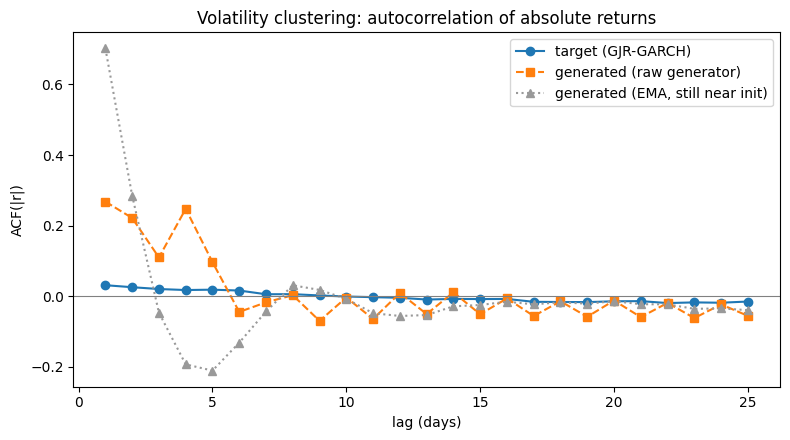

In [4]:
MAX_LAG = 25
acf_real, acf_fake = acf(real.abs(), MAX_LAG), acf(fake.abs(), MAX_LAG)
acf_ema = acf(fake_ema.abs(), MAX_LAG)
lags = range(1, MAX_LAG + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lags, acf_real[1:].numpy(), "o-", color="tab:blue", label="target (GJR-GARCH)")
ax.plot(lags, acf_fake[1:].numpy(), "s--", color="tab:orange", label="generated (raw generator)")
ax.plot(lags, acf_ema[1:].numpy(), "^:", color="0.6", label="generated (EMA, still near init)")
ax.axhline(0.0, color="0.5", lw=0.8)
ax.set_xlabel("lag (days)")
ax.set_ylabel("ACF(|r|)")
ax.set_title("Volatility clustering: autocorrelation of absolute returns")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "acf_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Tails: QQ-plot of pooled daily returns

Quantile against quantile (raw generator), pooled over paths and time steps.
Points on the diagonal mean the generator reproduces the unconditional return
distribution, including how far the tails reach.

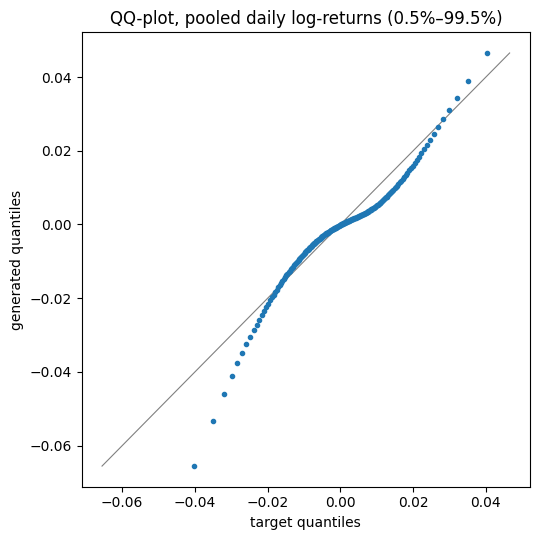

In [5]:
qs = torch.linspace(0.005, 0.995, 199, dtype=torch.float64)
q_real = torch.quantile(real.reshape(-1).double(), qs)
q_fake = torch.quantile(fake.reshape(-1).double(), qs)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lims = [float(min(q_real.min(), q_fake.min())), float(max(q_real.max(), q_fake.max()))]
ax.plot(lims, lims, color="0.5", lw=0.8)
ax.plot(q_real.numpy(), q_fake.numpy(), "o", ms=3)
ax.set_xlabel("target quantiles")
ax.set_ylabel("generated quantiles")
ax.set_title("QQ-plot, pooled daily log-returns (0.5%–99.5%)")
fig.tight_layout()
fig.savefig(FIG_DIR / "qq_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. One number: the debiased Sinkhorn divergence

`sinkhorn_divergence_metric` compresses distributional fit into one number on the
training objective's scale (the energy distance is 2× this divergence, with
critic embeddings in place of raw paths). It does not read 0 even for two
samples of the *same* process — entropic divergences have a finite-sample floor
that grows with path dimension — so the honest reading is the gap to that
floor, estimated here by splitting the held-out target paths in two. The
EMA/raw pair quantifies the lag discussed in section 3.

In [6]:
div_raw = sinkhorn_divergence_metric(fake, real, seed=0)
div_ema = sinkhorn_divergence_metric(fake_ema, real, seed=0)
div_floor = sinkhorn_divergence_metric(real[: n // 2], real[n // 2 :], seed=0)
print(f"sinkhorn divergence, raw generator vs target : {div_raw:.6f}")
print(f"sinkhorn divergence, EMA generator vs target : {div_ema:.6f}")
print(f"finite-sample floor, target vs target        : {div_floor:.6f}")

sinkhorn divergence, raw generator vs target : 0.049930
sinkhorn divergence, EMA generator vs target : 0.084312
finite-sample floor, target vs target        : 0.009587


## 7. The critic-sign ablation, replayed in minutes

The repo's headline result is a ~12-hour image ablation: the original notebook
descended a single loss with *both* optimizers, so the critic was trained in the
wrong direction; fixing the sign (`critic_sign=True`, critic ascends) cuts MNIST
FID from 185 to 77 (legacy n_eval=2048 protocol; 177.9 → 70.8 at the 10k
re-evaluation). Here is the same experiment replayed on market data in
minutes: two short runs under identical seeds and budgets, differing only in the
sign of the critic's gradient step. The correct arm is the run you just watched
train (section 2); the cell below reproduces the original bug
(`critic_sign=False`) with everything else unchanged.

Watch **three numbers** per arm, all computed on what each generator actually
learned: the final training objective D² (the minibatch energy distance on
critic embeddings — the loss both optimizers see), the lag-1 autocorrelation of
generated returns (real returns are nearly unpredictable: target ≈ −0.01), and
the data-space Sinkhorn divergence against held-out paths. The bug has a
signature: with the critic *descending*, the embeddings collapse and the
training loss reads near-zero — "perfect" — while the generator never learns to
kill the smooth, heavily autocorrelated structure of its initialization.

In [7]:
abl_cfg = FinanceConfig.from_yaml(REPO / "configs" / "finance_returns.yaml")
abl_cfg.critic_sign = False  # reproduce the original bug; everything else identical
abl_cfg.n_steps, abl_cfg.eval_every = cfg.n_steps, cfg.eval_every
abl_cfg.eval_dir, abl_cfg.ckpt_dir, abl_cfg.log_dir = (
    str(OUT / "ablation_off" / d) for d in ("eval", "ckpt", "logs")
)
buggy = ReturnsTrainer(abl_cfg)
d2_off = buggy.fit()[-1]["energy_distance"]
with torch.no_grad():  # judge what the buggy generator learned, not its EMA shadow
    smp_off = (buggy.generator(buggy.sample_z(n)) * buggy.scale).squeeze(1).cpu()
acf_off, div_off = acf(smp_off, 1)[1].item(), sinkhorn_divergence_metric(smp_off, real, seed=0)

d2_on, acf_on = history[-1]["energy_distance"], acf(fake, 1)[1].item()
Markdown(
    "| critic_sign | final training D² | ACF(r) lag-1 (target ≈ −0.01) | divergence vs held-out |\n"
    "| --- | ---: | ---: | ---: |\n"
    f"| **True** (correct — the run above) | {d2_on:+.4f} | {acf_on:+.4f} | {div_raw:.4f} |\n"
    f"| False (original bug, same budget/seed) | {d2_off:+.4f} | {acf_off:+.4f} | {div_off:.4f} |"
)

                             Finance configuration                              
              target: gjr_garch                     
            csv_path: None                          
             seq_len: 64                            
       n_train_paths: 8192                          
        n_eval_paths: 2048                          
         garch_omega: 5e-06                         
         garch_alpha: 0.05                          
          garch_beta: 0.9                           
         garch_gamma: 0.05                          
                  mu: 0.05                          
               sigma: 0.2                           
                  dt: 0.003968253968253968          
        heston_kappa: 2.0                           
        heston_theta: 0.04                          
           heston_xi: 0.3                           
          heston_rho: -0.7                          
                  s0: 100.0                         
          batch_si

step   100 | energy_distance=+0.0351 cross=+0.3063 real_real=+0.1340 fake_fake=+0.0016 sinkhorn_divergence_metric=+0.0502


step   200 | energy_distance=+0.0019 cross=+0.1774 real_real=+0.0625 fake_fake=+0.0253 sinkhorn_divergence_metric=+0.0486


step   300 | energy_distance=+0.0009 cross=+0.1882 real_real=+0.0528 fake_fake=+0.0408 sinkhorn_divergence_metric=+0.0588


step   400 | energy_distance=+0.0005 cross=+0.1735 real_real=+0.0478 fake_fake=+0.0387 sinkhorn_divergence_metric=+0.0600


step   500 | energy_distance=+0.0004 cross=+0.1658 real_real=+0.0446 fake_fake=+0.0381 sinkhorn_divergence_metric=+0.0587


| critic_sign | final training D² | ACF(r) lag-1 (target ≈ −0.01) | divergence vs held-out |
| --- | ---: | ---: | ---: |
| **True** (correct — the run above) | +0.5329 | -0.0022 | 0.0499 |
| False (original bug, same budget/seed) | +0.0004 | +0.9370 | 0.0460 |

## 8. Bring your own returns

The trainer also accepts a real return series (`target: csv`): a single
comma-separated series of daily log-returns, cut into non-overlapping windows of
`seq_len`. Uncomment to run on your own data — nothing else changes, which is
the point.

In [8]:
# own = FinanceConfig.from_yaml(REPO / "configs" / "finance_returns.yaml")
# own.target, own.csv_path = "csv", "/path/to/your_daily_log_returns.csv"
# own.eval_dir, own.ckpt_dir, own.log_dir = (str(OUT / "csv" / d) for d in ("eval", "ckpt", "logs"))
# own_trainer = ReturnsTrainer(own)
# own_trainer.fit()

## 9. Honest scorecard

This notebook deliberately trades training length for runnability: 500 steps
against the 3000 the committed config calls for (the training cell reports
5.5 min on the machine that produced this page). With the numbers actually
printed above:

**What the short run already delivers**

- *Decorrelated returns with fat tails.* Generated ACF(r) lag-1 = −0.002 against
  the target's −0.012 — the generator has learned that returns must not be
  linearly predictable, which its smooth convolutional initialization very much
  was. Pooled excess kurtosis +7.07 against +1.00: tail mass appears with the
  right sign and an overshoot, the typical mid-training profile.
- *Volatility clustering and leverage, right sign, exaggerated magnitude.*
  ACF(|r|) lag-1 +0.27 vs +0.03, decaying to ~0 by lag 10 like the target;
  leverage correlation −0.29 vs −0.02 at lag 1. Every lag-1/headline stylized
  fact in the table has the correct sign at 1/6 of the training budget (the
  near-zero long-lag ACF rows, lags 10/20, fluctuate around zero with mixed
  signs) — and every magnitude is overshot. The network finds the *direction* of each effect before
  it calibrates the *size*.
- *The critic-sign mechanism, replayed.* Under an identical budget and seed, the
  buggy run's training loss collapses to +0.0004 — it looks "solved" — while
  its samples carry lag-1 autocorrelation +0.94: smooth curves, not returns.
  The correct run holds the objective at +0.53 and kills that autocorrelation
  (−0.002). That is the mechanism behind the repo's ~12-hour image ablation
  (FID 185 → 77, legacy n_eval=2048 protocol; 177.9 → 70.8 at the 10k
  re-evaluation), reproduced in minutes.

**What it does not deliver (yet)**

- *Calibrated magnitudes.* Kurtosis, ACF(|r|), ACF(r²) and leverage all overshoot
  by factors of 3–10. Matching the *decay profile* of temporal dependence, not
  just its sign, is exactly what COT-GAN's causal (adapted) transport constraint
  targets (Xu et al. 2020) — the natural next step for this engine on market data.
- *Convergence.* Divergence 0.050 (raw generator) and 0.084 (EMA) against a
  same-process floor of 0.0096: the run is visibly mid-flight. Note also the
  honest detail in the ablation table: at this budget the buggy arm's data-space
  divergence (0.046) is not worse than the correct arm's (0.050) — a
  generator that collapses near its initialization can transiently sit no
  further from the data than one in mid-stride. The loss column and the
  autocorrelation column are what separate them; the divergence gap is what the
  full-length runs (and the image FID ablation) open up.
- *The EMA convention.* The EMA shadow — the right thing to sample at full
  length — still mostly carries its initialization here (0.999 to the power of
  ~330 generator steps ≈ 0.72 of the init weight), which is why the figures
  label it separately.

For the real run, load `configs/finance_returns.yaml` unchanged — 3000 steps,
roughly half an hour on a laptop CPU — and call `ReturnsTrainer(cfg).fit()`. The
engine, the metrics and the scorecard's honesty policy stay exactly the same:
*the same OT engine, from images to markets*.